# Homework: Unsupervised Models for Time-Series

This notebook contains a short homework assignment and full solutions.

Covered topics:

- Anomaly detection: point, contextual, and collective anomalies
- Change-point detection: binary segmentation
- Time-series distances: Euclidean, Manhattan, correlation, DTW
- Time-series clustering and cluster-quality evaluation


## Setup

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

np.random.seed(42)


# Data Generation

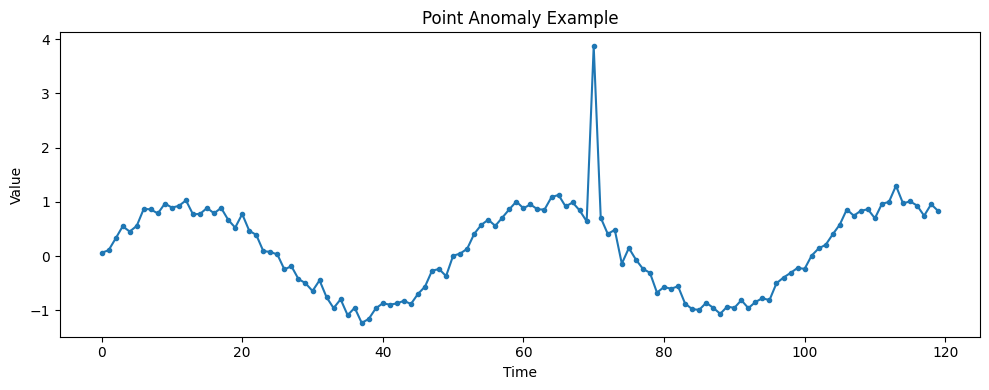

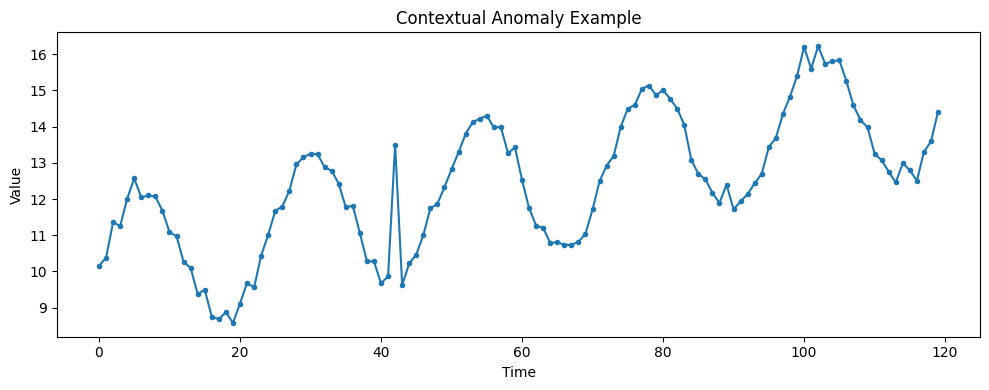

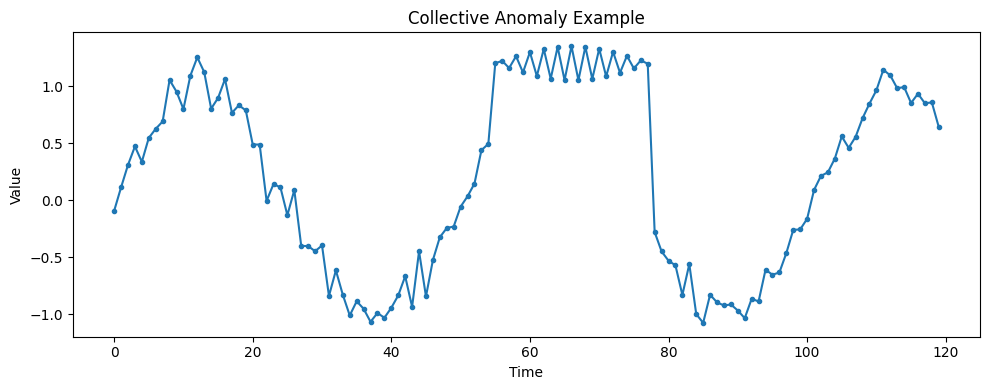

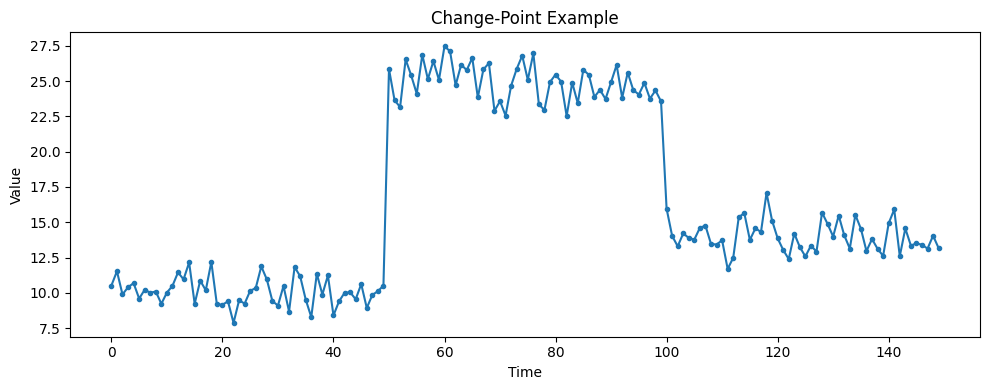

In [38]:
t = np.arange(120)

# Point anomaly
y_point = np.sin(t / 8) + np.random.normal(0, 0.12, len(t))
y_point[70] += 3.2

# Contextual anomaly
y_context = 10 + 0.04 * t + 2 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 0.2, len(t))
y_context[42] = 13.5

# Collective anomaly
y_collective = np.sin(t / 8) + np.random.normal(0, 0.12, len(t))
start, end = 55, 78
y_collective[start:end] = 1.2 + 0.15 * np.sin(np.arange(end - start) * 3)

# Change-point signal
y_cpd = np.concatenate([
    np.random.normal(10, 1.0, 50),
    np.random.normal(25, 1.2, 50),
    np.random.normal(14, 1.0, 50),
])
true_cps = [50, 100]

def plot_series(y, title):
    plt.figure(figsize=(10, 4))
    plt.plot(y, marker="o", markersize=3)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

plot_series(y_point, "Point Anomaly Example")
plot_series(y_context, "Contextual Anomaly Example")
plot_series(y_collective, "Collective Anomaly Example")
plot_series(y_cpd, "Change-Point Example")


## Question 1 - Point Anomaly Detection
Use a rolling z-score to detect the point anomaly in `y_point`.

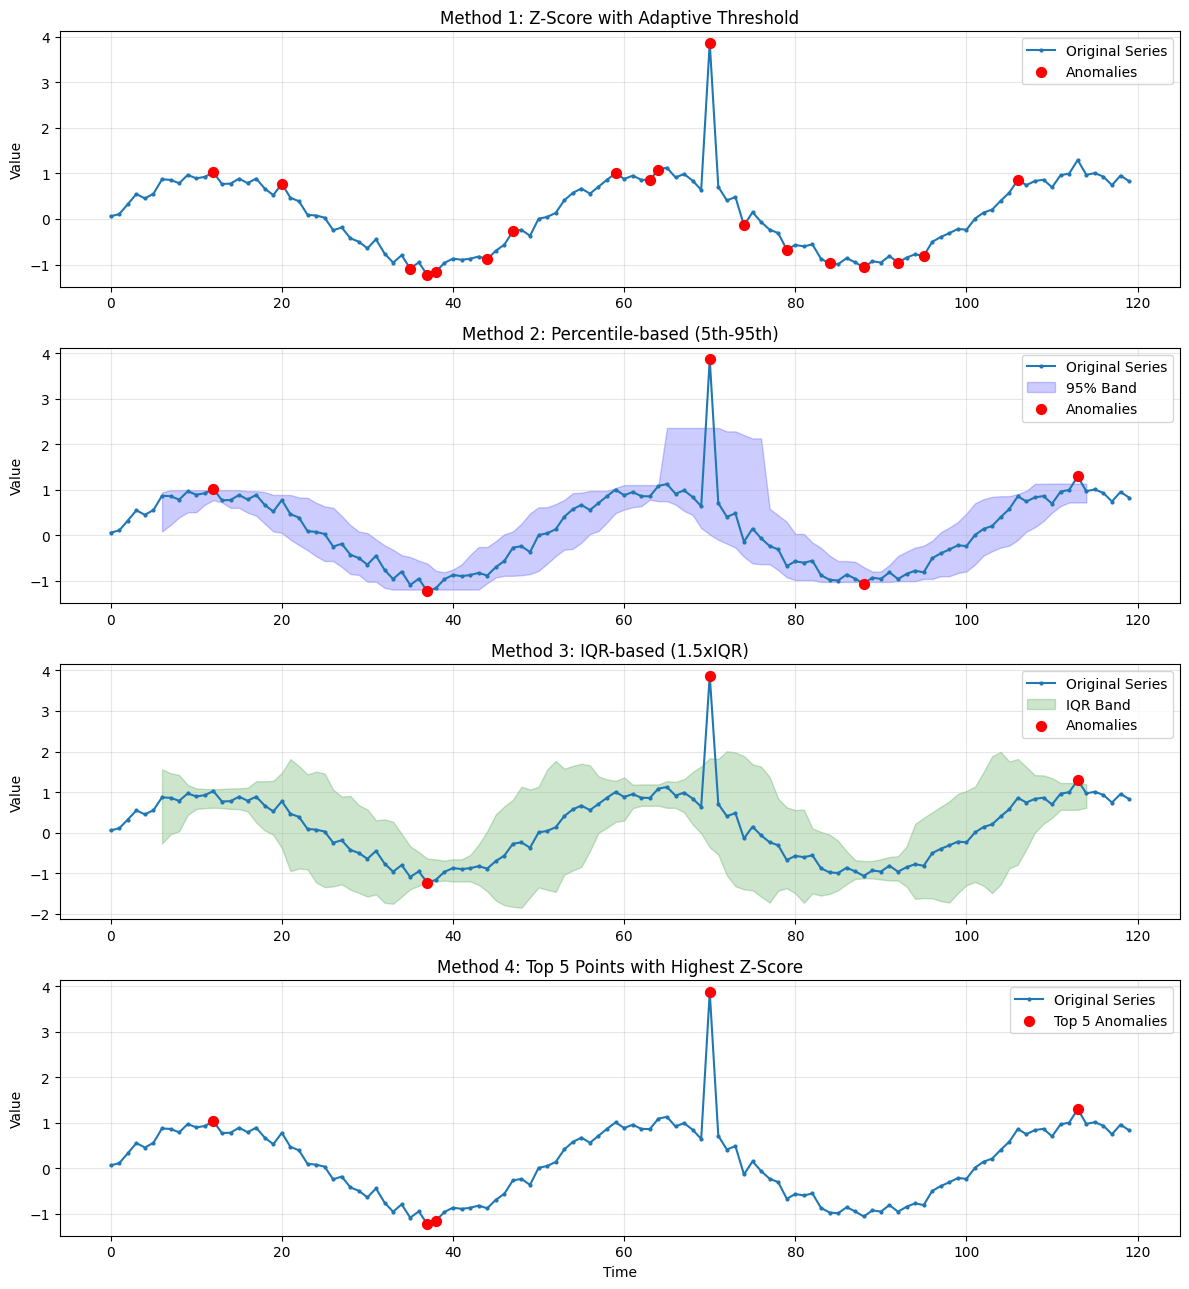

Method 1 (Z-Score Adaptive): [12, 20, 35, 37, 38, 44, 47, 59, 63, 64, 70, 74, 79, 84, 88, 92, 95, 106]
Method 2 (Percentile): [12, 37, 70, 88, 113]
Method 3 (IQR): [37, 70, 113]
Method 4 (Top 5 Z-Score): [12, 37, 38, 70, 113]


In [39]:
# Question 1: Point Anomaly Detection - Multiple Methods Comparison

window_size = 12

# Compute rolling mean and std
rolling_mean = pd.Series(y_point).rolling(window=window_size, center=True).mean()
rolling_std = pd.Series(y_point).rolling(window=window_size, center=True).std()

# ========== Method 1: Z-Score with Adaptive Threshold ==========
z_score = (y_point - rolling_mean) / (rolling_std + 1e-10)
median_abs_z = pd.Series(np.abs(z_score)).rolling(window=window_size, center=True).median()
threshold_adaptive = 2.0 * median_abs_z
anomalies_zscore = np.abs(z_score) > threshold_adaptive

# ========== Method 2: Percentile-based Threshold ==========
p95, p05 = pd.Series(y_point).rolling(window=window_size, center=True).quantile(0.95), pd.Series(y_point).rolling(window=window_size, center=True).quantile(0.05)
anomalies_percentile = (y_point > p95) | (y_point < p05)

# ========== Method 3: IQR-based Detection ==========
rolling_q1 = pd.Series(y_point).rolling(window=window_size, center=True).quantile(0.25)
rolling_q3 = pd.Series(y_point).rolling(window=window_size, center=True).quantile(0.75)
rolling_iqr = rolling_q3 - rolling_q1
lower_bound = rolling_q1 - 1.5 * rolling_iqr
upper_bound = rolling_q3 + 1.5 * rolling_iqr
anomalies_iqr = (y_point < lower_bound) | (y_point > upper_bound)

# ========== Method 4: Top X Points with Highest Z-Score ==========
num_of_anomalies = 5  # Number of anomalies to select
z_abs = pd.Series(np.abs(z_score)).dropna()
top_X_indices = z_abs.nlargest(num_of_anomalies).index
anomalies_top_x = np.zeros(len(y_point), dtype=bool)
anomalies_top_x[top_X_indices] = True

# ========== Visualization: Compare all methods ==========
fig, axes = plt.subplots(4, 1, figsize=(12, 13))

# Plot 1: Z-Score with Adaptive Threshold
axes[0].plot(y_point, marker="o", markersize=2, label="Original Series")
axes[0].scatter(np.where(anomalies_zscore)[0], y_point[anomalies_zscore], color="red", s=50, label="Anomalies", zorder=5)
axes[0].set_title("Method 1: Z-Score with Adaptive Threshold")
axes[0].set_ylabel("Value")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Percentile-based
axes[1].plot(y_point, marker="o", markersize=2, label="Original Series")
axes[1].fill_between(range(len(y_point)), p05, p95, alpha=0.2, color="blue", label="95% Band")
axes[1].scatter(np.where(anomalies_percentile)[0], y_point[anomalies_percentile], color="red", s=50, label="Anomalies", zorder=5)
axes[1].set_title("Method 2: Percentile-based (5th-95th)")
axes[1].set_ylabel("Value")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: IQR-based
axes[2].plot(y_point, marker="o", markersize=2, label="Original Series")
axes[2].fill_between(range(len(y_point)), lower_bound, upper_bound, alpha=0.2, color="green", label="IQR Band")
axes[2].scatter(np.where(anomalies_iqr)[0], y_point[anomalies_iqr], color="red", s=50, label="Anomalies", zorder=5)
axes[2].set_title("Method 3: IQR-based (1.5xIQR)")
axes[2].set_ylabel("Value")
axes[2].legend()
axes[2].grid(alpha=0.3)

# Plot 4: Top X Points with Highest Z-Score
axes[3].plot(y_point, marker="o", markersize=2, label="Original Series")
axes[3].scatter(np.where(anomalies_top_x)[0], y_point[anomalies_top_x], color="red", s=50, label=f"Top {num_of_anomalies} Anomalies", zorder=5)
axes[3].set_title(f"Method 4: Top {num_of_anomalies} Points with Highest Z-Score")
axes[3].set_xlabel("Time")
axes[3].set_ylabel("Value")
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print results
print(f"Method 1 (Z-Score Adaptive): {np.where(anomalies_zscore)[0].tolist()}")
print(f"Method 2 (Percentile): {np.where(anomalies_percentile)[0].tolist()}")
print(f"Method 3 (IQR): {np.where(anomalies_iqr)[0].tolist()}")
print(f"Method 4 (Top {num_of_anomalies} Z-Score): {np.where(anomalies_top_x)[0].tolist()}")

## Question 2 - Contextual Anomaly Detection
Use STL decomposition with `period=24`, then apply z-score detection on the residuals.

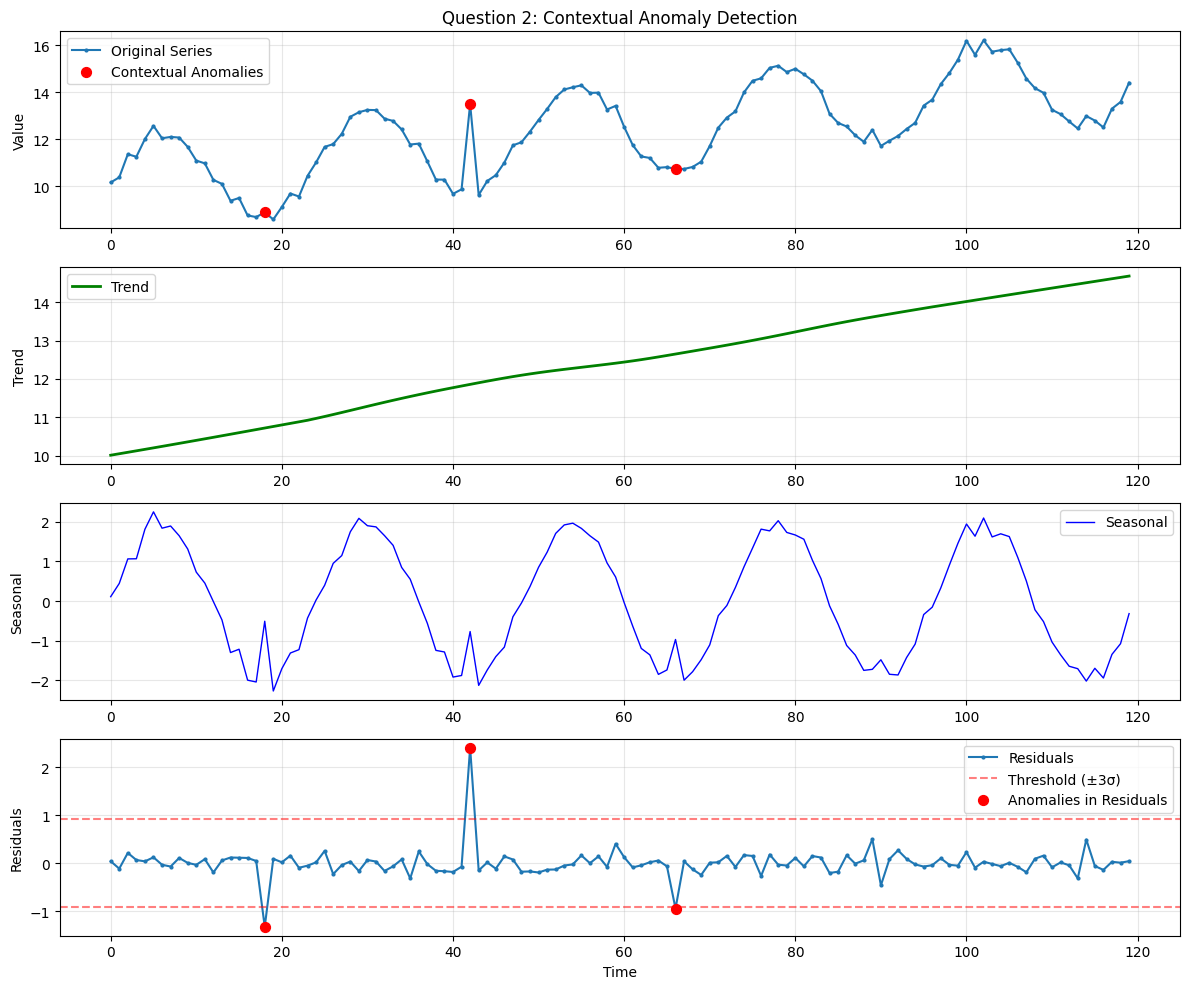

Contextual anomalies detected at indices: [18, 42, 66]
Number of anomalies: 3


In [40]:
# STL decomposition
result = STL(y_context, period=24).fit()
trend = result.trend
seasonal = result.seasonal
residuals = result.resid

# Apply z-score detection on residuals
threshold = 3
residual_zscore = (residuals - residuals.mean()) / residuals.std()
contextual_anomalies = np.abs(residual_zscore) > threshold

# Visualization
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Plot 1: Original series with anomalies
axes[0].plot(y_context, marker="o", markersize=2, label="Original Series")
axes[0].scatter(np.where(contextual_anomalies)[0], y_context[contextual_anomalies], 
                color="red", s=50, label="Contextual Anomalies", zorder=5)
axes[0].set_title("Question 2: Contextual Anomaly Detection")
axes[0].set_ylabel("Value")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Trend component
axes[1].plot(trend, color="green", linewidth=2, label="Trend")
axes[1].set_ylabel("Trend")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Seasonal component
axes[2].plot(seasonal, color="blue", linewidth=1, label="Seasonal")
axes[2].set_ylabel("Seasonal")
axes[2].legend()
axes[2].grid(alpha=0.3)

# Plot 4: Residuals with anomalies
axes[3].plot(residuals, marker="o", markersize=2, label="Residuals")
axes[3].axhline(y=threshold * residuals.std(), color="red", linestyle="--", alpha=0.5, label=f"Threshold (±{threshold}σ)")
axes[3].axhline(y=-threshold * residuals.std(), color="red", linestyle="--", alpha=0.5)
axes[3].scatter(np.where(contextual_anomalies)[0], residuals[contextual_anomalies], 
                color="red", s=50, label="Anomalies in Residuals", zorder=5)
axes[3].set_xlabel("Time")
axes[3].set_ylabel("Residuals")
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Contextual anomalies detected at indices: {np.where(contextual_anomalies)[0].tolist()}")
print(f"Number of anomalies: {contextual_anomalies.sum()}")

## Question 3 - Collective Anomaly Detection
Extract rolling-window features and use `IsolationForest` to detect the anomalous segment.


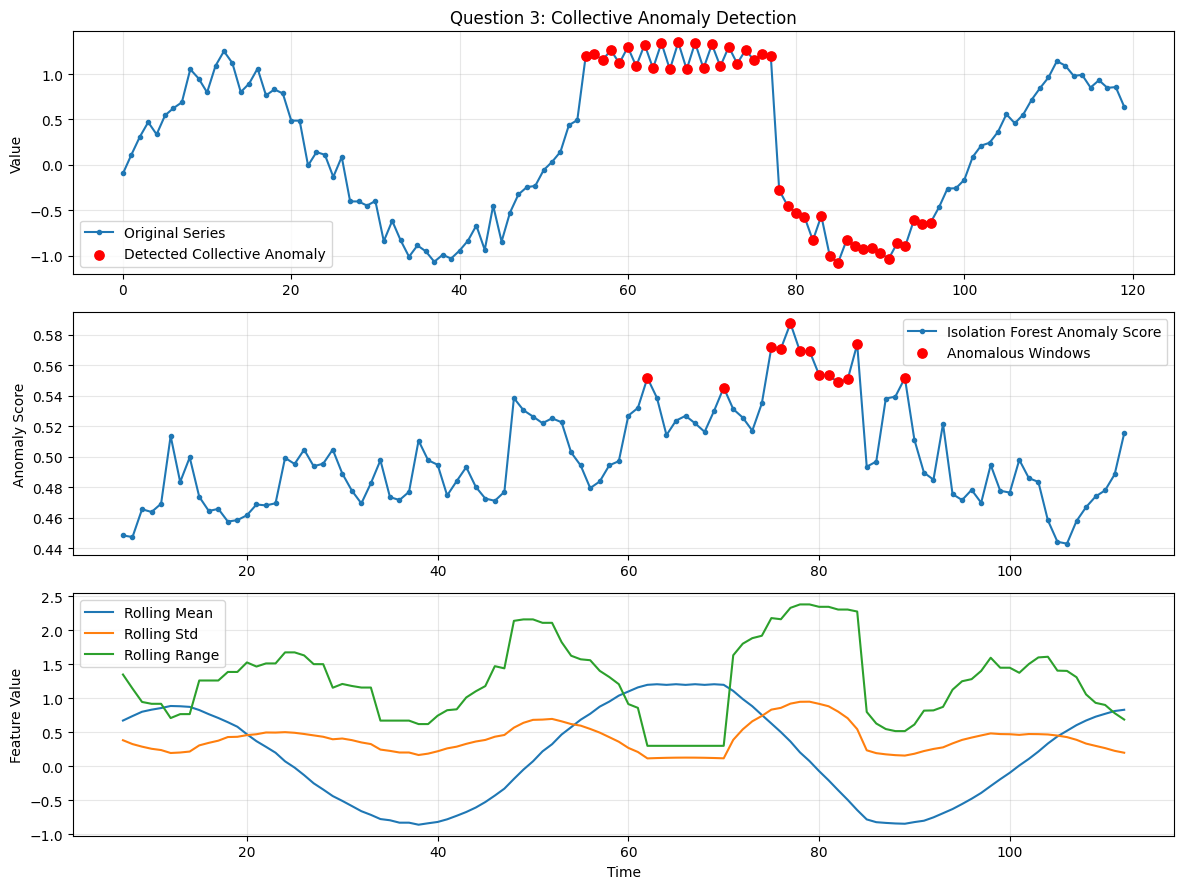

Anomalous window centers: [62, 70, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 89]
Number of anomalous windows: 13
Detected anomalous point indices: [55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96]
Number of detected anomalous points: 42


In [41]:
# Rolling-window feature extraction
window_size = 15

features = []
window_starts = []
window_centers = []

for i in range(len(y_collective) - window_size + 1):
    window = y_collective[i:i + window_size]
    x = np.arange(window_size)
    
    features.append({
        "mean": np.mean(window),
        "std": np.std(window),
        "min": np.min(window),
        "max": np.max(window),
        "range": np.max(window) - np.min(window),
        "slope": np.polyfit(x, window, 1)[0]})
    
    window_starts.append(i)
    window_centers.append(i + window_size // 2)

features_df = pd.DataFrame(features, index=window_centers)

# Fit Isolation Forest on rolling-window features
iso_model = IsolationForest(contamination=0.12,random_state=42)

window_labels = iso_model.fit_predict(features_df)
window_scores = -iso_model.score_samples(features_df)
anomalous_windows = window_labels == -1

# Convert anomalous windows into anomalous points
collective_anomalies = np.zeros(len(y_collective), dtype=bool)

for start_idx, is_anomaly in zip(window_starts, anomalous_windows):
    if is_anomaly:
        collective_anomalies[start_idx:start_idx + window_size] = True

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# Plot 1: Original series with detected collective anomaly
axes[0].plot(y_collective, marker="o", markersize=3, label="Original Series")
axes[0].scatter(np.where(collective_anomalies)[0], y_collective[collective_anomalies],
                color="red", s=45, label="Detected Collective Anomaly", zorder=5)
axes[0].set_title("Question 3: Collective Anomaly Detection")
axes[0].set_ylabel("Value")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Rolling-window anomaly scores
axes[1].plot(features_df.index, window_scores, marker="o", markersize=3, label="Isolation Forest Anomaly Score")
axes[1].scatter(features_df.index[anomalous_windows], window_scores[anomalous_windows], 
                color="red", s=45, label="Anomalous Windows", zorder=5)
axes[1].set_ylabel("Anomaly Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Rolling-window features
axes[2].plot(features_df.index, features_df["mean"], label="Rolling Mean")
axes[2].plot(features_df.index, features_df["std"], label="Rolling Std")
axes[2].plot(features_df.index, features_df["range"], label="Rolling Range")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Feature Value")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Anomalous window centers: {features_df.index[anomalous_windows].tolist()}")
print(f"Number of anomalous windows: {anomalous_windows.sum()}")
print(f"Detected anomalous point indices: {np.where(collective_anomalies)[0].tolist()}")
print(f"Number of detected anomalous points: {collective_anomalies.sum()}")

## Question 4 - Change-Point Detection
Implement simple binary segmentation to detect two change points in `y_cpd`.

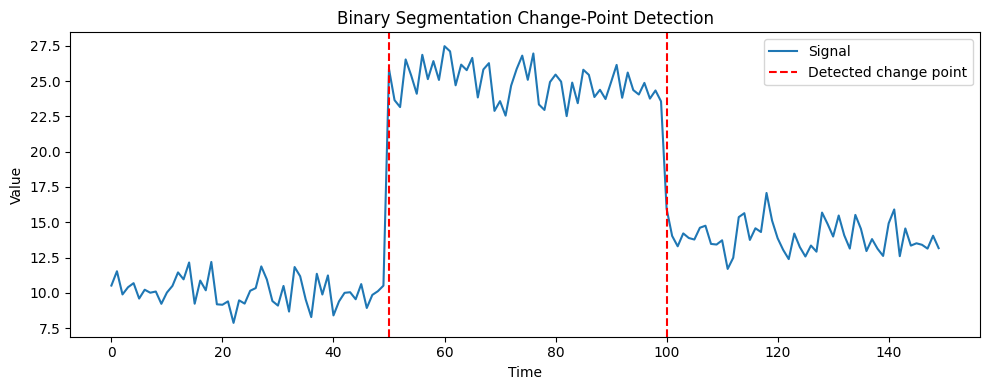

Detected change points: [50, 100]


In [42]:
def segment_cost(segment):
    # Sum of squared errors from the segment mean
    return np.sum((segment - np.mean(segment)) ** 2)


def find_best_split(y, start, end, min_size=10):
    # Find the split that gives the largest reduction in error
    original_cost = segment_cost(y[start:end])
    best_split = None
    best_gain = 0

    for split in range(start + min_size, end - min_size + 1):
        left_cost = segment_cost(y[start:split])
        right_cost = segment_cost(y[split:end])
        gain = original_cost - left_cost - right_cost

        if gain > best_gain:
            best_gain = gain
            best_split = split

    return best_split, best_gain


def binary_segmentation(y, n_change_points=2, min_size=8):
    segments = [(0, len(y))]
    change_points = []

    for _ in range(n_change_points):
        candidates = []

        for start, end in segments:
            split, gain = find_best_split(y, start, end, min_size)
            if split is not None:
                candidates.append((gain, split, start, end))

        if not candidates:
            break

        gain, split, start, end = max(candidates)
        segments.remove((start, end))
        segments.extend([(start, split), (split, end)])
        change_points.append(split)

    return sorted(change_points)


detected_cps = binary_segmentation(y_cpd, n_change_points=2)

plt.figure(figsize=(10, 4))
plt.plot(y_cpd, label="Signal")
for i, cp in enumerate(detected_cps):
    plt.axvline(cp, color="red", linestyle="--",
                label="Detected change point" if i == 0 else None)
plt.title("Binary Segmentation Change-Point Detection")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

print("Detected change points:", detected_cps)

## Question 5 - Time-Series Distances
Implement Euclidean, Manhattan, correlation, and DTW distances.

In [43]:
def euclidean_distance(series_a, series_b):
    # Square root of the sum of squared differences
    return np.sqrt(np.sum((series_a - series_b) ** 2))


def manhattan_distance(series_a, series_b):
    # Sum of absolute differences
    return np.sum(np.abs(series_a - series_b))


def correlation_distance(series_a, series_b):
    # Similar series have correlation distance close to zero
    correlation = np.corrcoef(series_a, series_b)[0, 1]
    return 1 - correlation


def dtw_distance(series_a, series_b):
    # Store the smallest alignment cost for every pair of positions
    rows = len(series_a) + 1
    columns = len(series_b) + 1
    dtw_matrix = np.full((rows, columns), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, rows):
        for j in range(1, columns):
            current_cost = abs(series_a[i - 1] - series_b[j - 1])
            previous_cost = min(
                dtw_matrix[i - 1, j],
                dtw_matrix[i, j - 1],
                dtw_matrix[i - 1, j - 1]
            )
            dtw_matrix[i, j] = current_cost + previous_cost

    return dtw_matrix[-1, -1]


series = {
    "y_point": y_point,
    "y_context": y_context,
    "y_collective": y_collective,
    "y_cpd": y_cpd
}

series_names = list(series.keys())
distance_results = []

for i in range(len(series_names)):
    for j in range(i + 1, len(series_names)):
        name_a = series_names[i]
        name_b = series_names[j]
        series_a = series[name_a]
        series_b = series[name_b]

        # Pointwise distances require equal-length series
        common_length = min(len(series_a), len(series_b))
        aligned_a = series_a[:common_length]
        aligned_b = series_b[:common_length]

        distance_results.append({
            "Series A": name_a,
            "Series B": name_b,
            "Euclidean": euclidean_distance(aligned_a, aligned_b),
            "Manhattan": manhattan_distance(aligned_a, aligned_b),
            "Correlation": correlation_distance(aligned_a, aligned_b),
            "DTW": dtw_distance(series_a, series_b)
        })

distance_results_df = pd.DataFrame(distance_results)
distance_results_df

,Series A,Series B,Euclidean,Manhattan,Correlation,DTW
0,y_point,y_context,136.516491,1475.179033,1.092112,1475.179033
1,y_point,y_collective,4.404983,26.969767,0.119736,18.969222
2,y_point,y_cpd,199.729522,2020.850190,0.982413,2318.870564
3,y_context,y_collective,135.522649,1465.002454,1.029622,1465.002454
4,y_context,y_cpd,86.423205,699.879536,0.598930,602.805388
5,y_collective,y_cpd,198.468747,2010.673611,0.862816,2384.237124



## Question 6 - Time-Series Clustering
Generate three groups of time-series, cluster them with KMeans, and evaluate with Silhouette.

Dataset shape: (75, 100)
Silhouette Score: 0.76


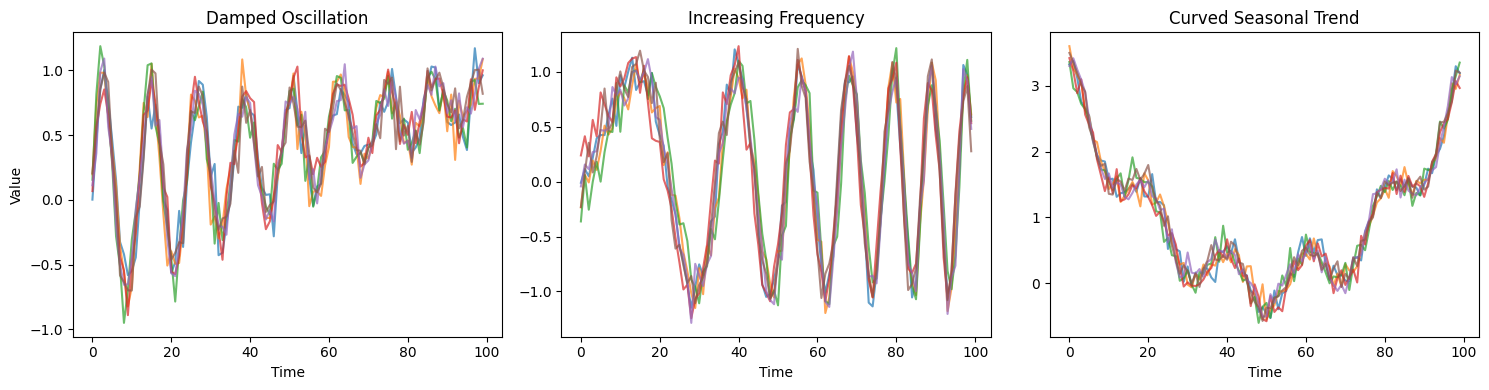

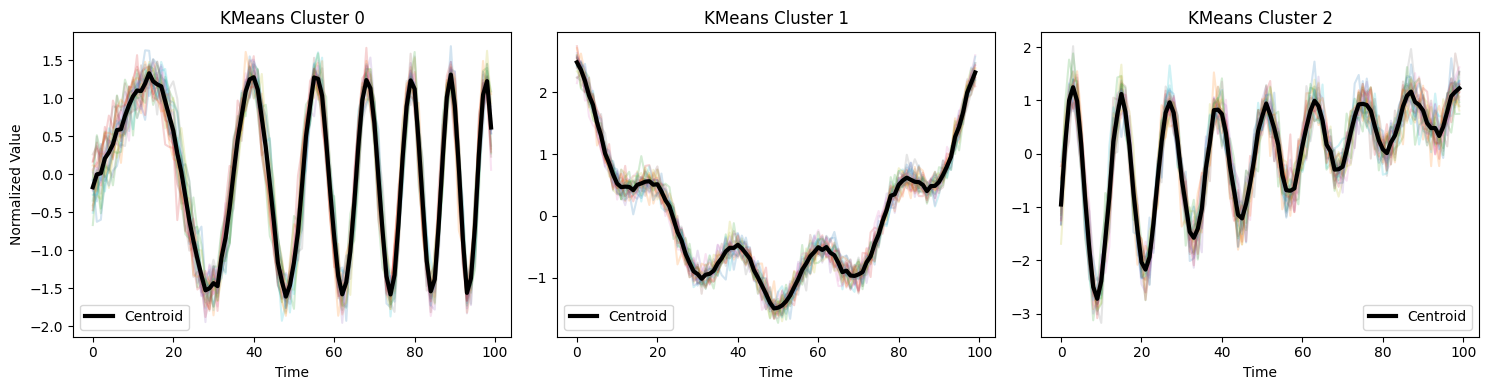

In [44]:
n_per_group = 25
series_length = 100
time = np.arange(series_length)

all_series = []
true_groups = []

# Group 0: damped oscillations with a small trend
for _ in range(n_per_group):
    phase = np.random.uniform(-0.25, 0.25)
    noise = np.random.normal(0, 0.12, series_length)
    oscillation = np.exp(-time / 55) * np.sin(2 * np.pi * time / 12 + phase)
    y = oscillation + 0.008 * time + noise
    all_series.append(y)
    true_groups.append(0)

# Group 1: oscillations whose frequency increases over time
for _ in range(n_per_group):
    phase = np.random.uniform(-0.25, 0.25)
    noise = np.random.normal(0, 0.12, series_length)
    y = np.sin(0.06 * time + 0.0035 * time ** 2 + phase) + noise
    all_series.append(y)
    true_groups.append(1)

# Group 2: curved trends with seasonality
for _ in range(n_per_group):
    phase = np.random.uniform(-0.25, 0.25)
    noise = np.random.normal(0, 0.12, series_length)
    curved_trend = 0.0012 * (time - 50) ** 2
    seasonal = 0.4 * np.cos(2 * np.pi * time / 20 + phase)
    y = curved_trend + seasonal + noise
    all_series.append(y)
    true_groups.append(2)

X_cluster = np.array(all_series)
true_groups = np.array(true_groups)

# Normalize each series so clustering focuses on shape
series_means = X_cluster.mean(axis=1, keepdims=True)
series_stds = X_cluster.std(axis=1, keepdims=True)
X_cluster_norm = (X_cluster - series_means) / (series_stds + 1e-10)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_cluster_norm)
silhouette = silhouette_score(X_cluster_norm, cluster_labels)

print("Dataset shape:", X_cluster.shape)
print("Silhouette Score:", round(silhouette, 3))

# Plot examples from the generated groups
group_titles = ["Damped Oscillation", "Increasing Frequency", "Curved Seasonal Trend"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for group in range(3):
    indices = np.where(true_groups == group)[0][:6]
    for index in indices:
        axes[group].plot(X_cluster[index], alpha=0.7)
    axes[group].set_title(group_titles[group])
    axes[group].set_xlabel("Time")

axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

# Plot the clusters and their centroids
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cluster in range(3):
    indices = np.where(cluster_labels == cluster)[0]
    for index in indices:
        axes[cluster].plot(X_cluster_norm[index], alpha=0.2)
    axes[cluster].plot(
        kmeans.cluster_centers_[cluster],
        color="black",
        linewidth=3,
        label="Centroid"
    )
    axes[cluster].set_title(f"KMeans Cluster {cluster}")
    axes[cluster].set_xlabel("Time")
    axes[cluster].legend()

axes[0].set_ylabel("Normalized Value")
plt.tight_layout()
plt.show()

# Final Summary

This homework covered the main unsupervised time-series ideas:

| Topic | Method |
|---|---|
| Point anomaly | Rolling z-score |
| Contextual anomaly | STL + residual z-score |
| Collective anomaly | Rolling features + Isolation Forest |
| CPD | Binary segmentation |
| Distance measures | Euclidean, Manhattan, correlation, DTW |
| Clustering | KMeans on normalized series |
| Evaluation | Silhouette Score and ARI |
